In [48]:
import numpy as np

# Constants
wave = 1040e-9  # wavelength in meters (1040 nm)

# Case A: Given lpm, solve for θ = θ'
lpm_ed = 1503.76  # lines per mm at Edmund Optics website https://www.edmundoptics.com/p/ii-vi-lightsmytht-875nm-150376-groovesmm-248-x-158mm-transmission-diffraction-grating/44726/
d = 1 / (lpm_ed * 1e3)  # grating spacing in meters

sin_theta = wave / (2 * d)
theta_rad = np.arcsin(sin_theta)
theta_deg = np.degrees(theta_rad)

# --- Print results ---
print("--- Grating Geometry - Littrow Angle ---")
print(f"Case A: For lpm = {lpm_ed:.2f}, θ = θ' = {theta_deg:.6f} deg")

--- Grating Geometry - Littrow Angle ---
Case A: For lpm = 1503.76, θ = θ' = 51.439942 deg


https://ntrs.nasa.gov/api/citations/20070018851/downloads/20070018851.pdf

https://nvlpubs.nist.gov/nistpubs/jres/75a/jresv75an4p279_a1b.pdf

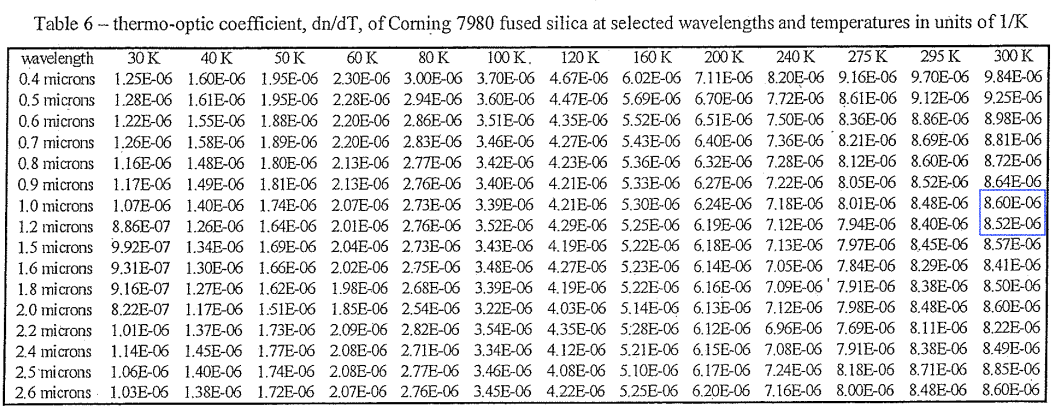

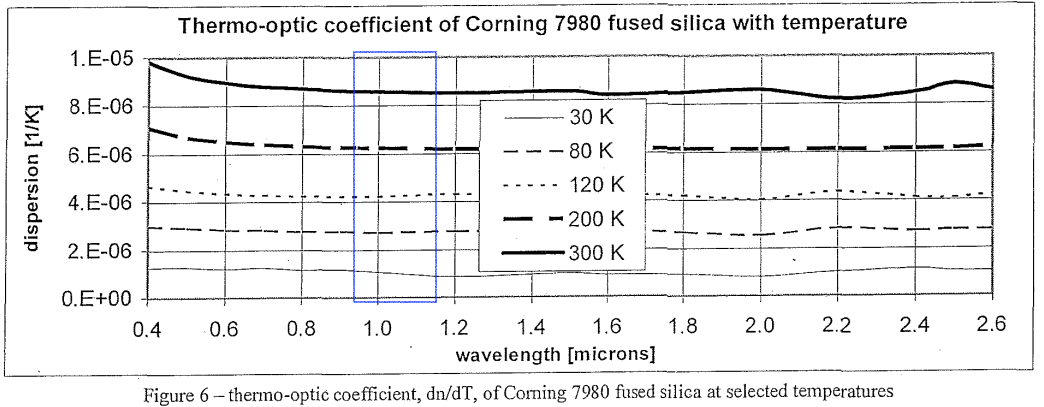

https://accuratus.com/fused.html

https://link.springer.com/article/10.1007/s10765-024-03422-3 (See Measurement set up below)

https://www.translume.com/component/k2/item/186-fused-silica-material-properties#:~:text=Coefficient%20of%20Thermal%20Expansion%20(CTE)&text=Fused%20Silica%20Mean%20Coefficient%20of,200%C2%B0C%20temperature%20range

Setup for the thermal expansion measurement. Two Fabry–Perot cavities were formed out of excess (cell) tubing material, and suspended side by side. The sketched assembly was placed inside an inner shell and vacuum chamber, which was submerged in a water bath. Temperature of the water bath was varied between -10˚C and 40˚C


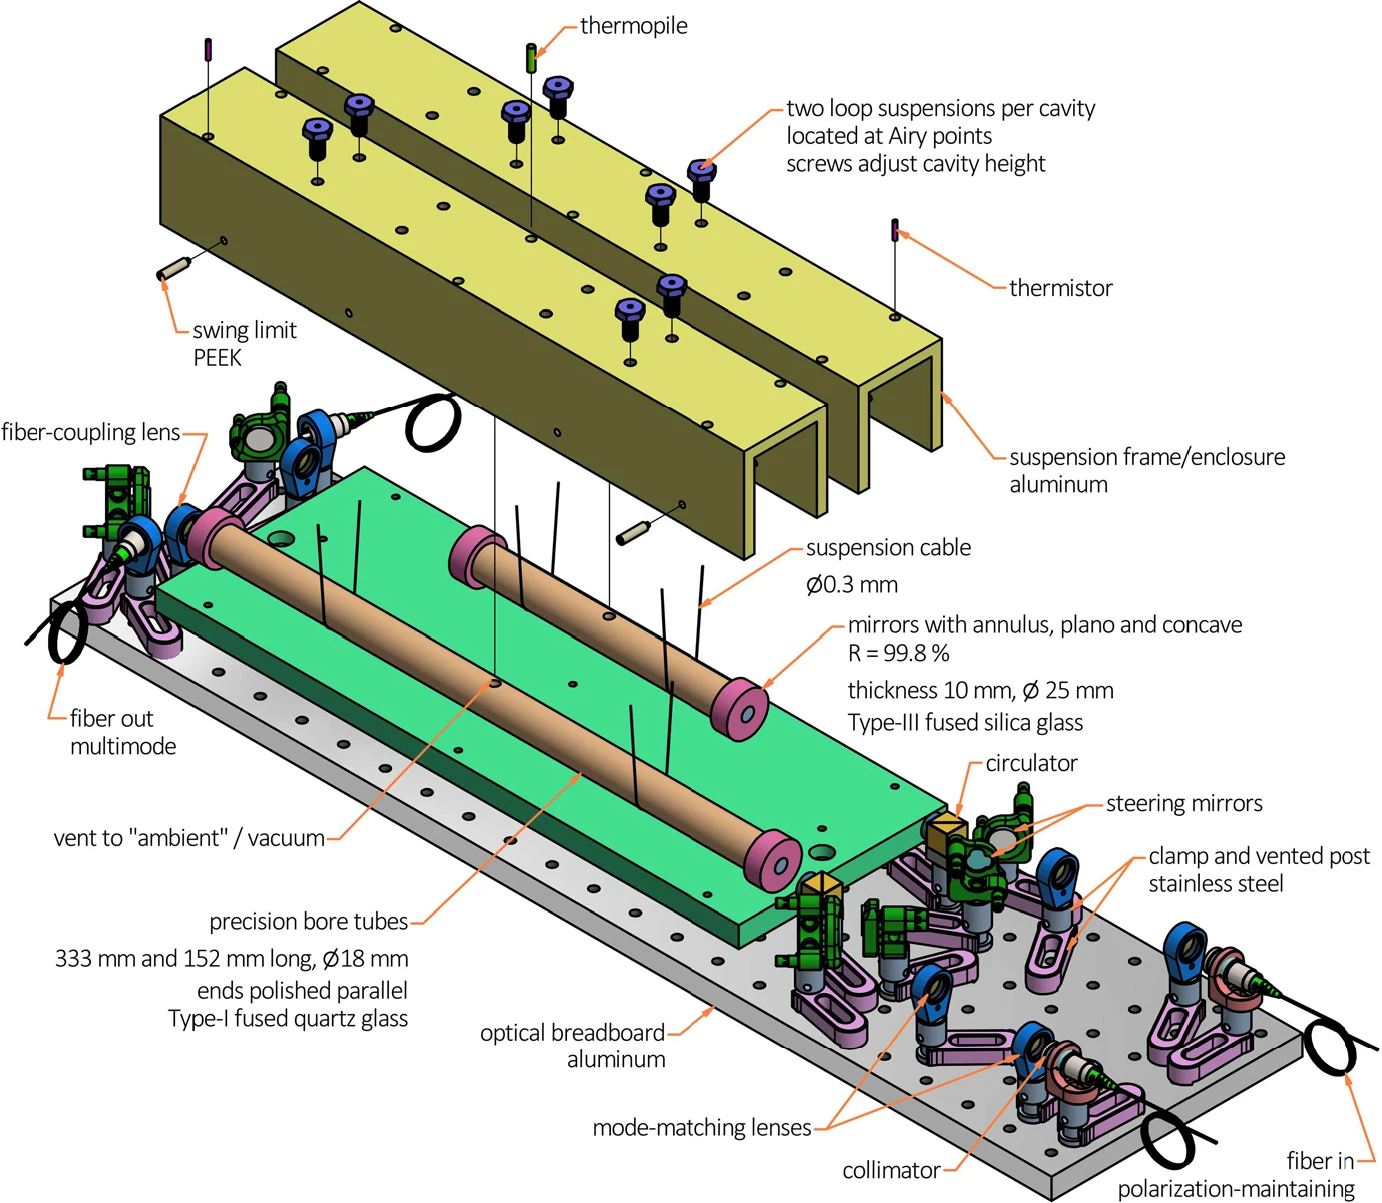

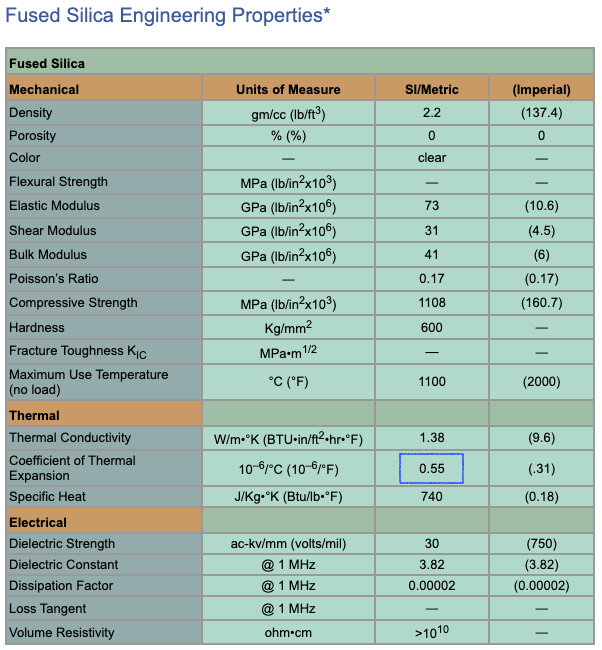

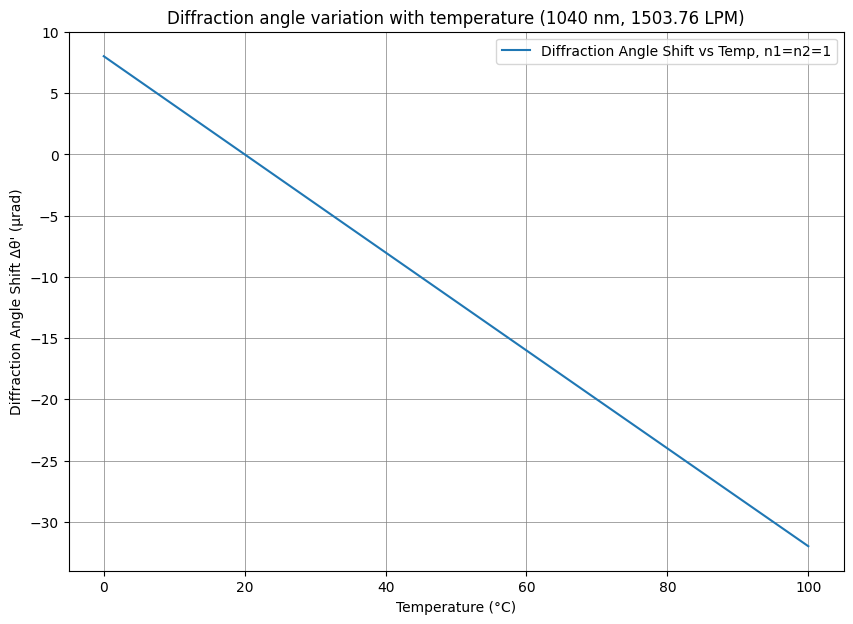

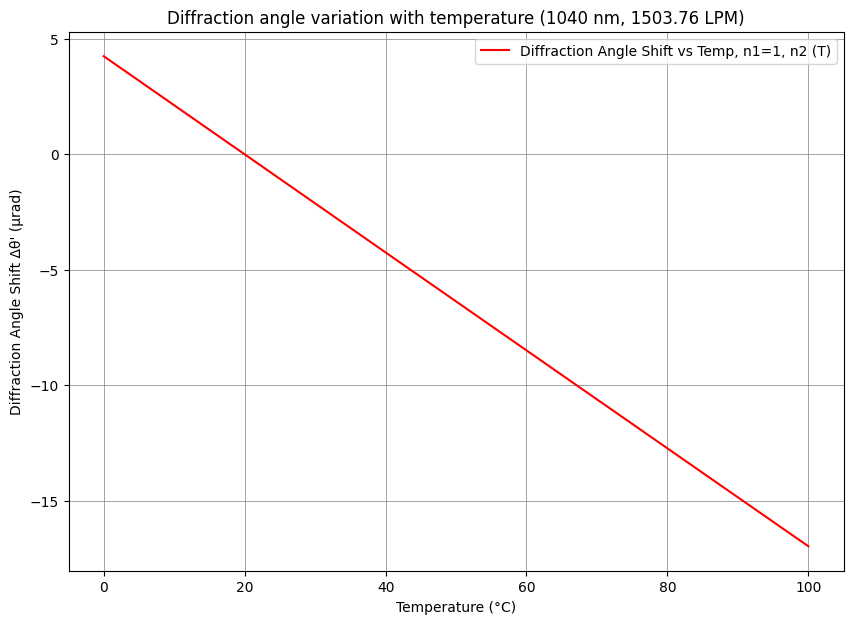

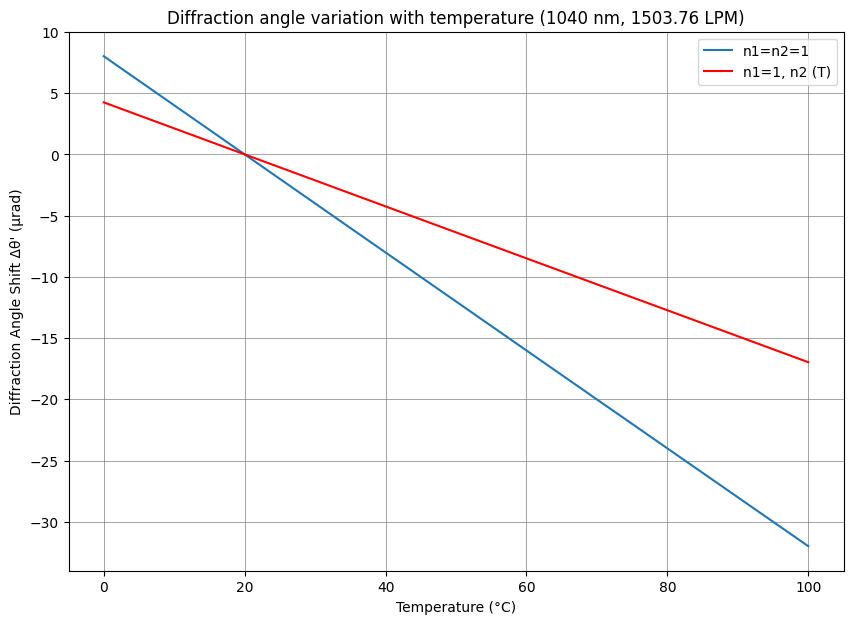

In [49]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
m = 1                             # diffraction order
wave = 1040e-9                    # meters
lines_per_mm = 1503.76            # grating period for 1503.76 lines/mm from https://www.edmundoptics.com/p/ii-vi-lightsmytht-875nm-150376-groovesmm-248-x-158mm-transmission-diffraction-grating/44726/
d0 = 1e-3 / lines_per_mm          # initial groove spacing (m)
arcsec_per_rad = 3600*180/np.pi   # 1 rad = 206265 arcsec
theta_deg = 51.439942             # incidence angle in radians

# (Littrow) Angle for 1040 nm and LPM of 1503.76 
theta_lit = np.deg2rad(theta_deg) # incidence angle in radians

# Material properties
alpha = 0.55e-6                   # thermal expansion coeff (/°C); from https://accuratus.com/fused.html and https://www.translume.com/component/k2/item/186-fused-silica-material-properties#:~:text=Coefficient%20of%20Thermal%20Expansion%20(CTE)&text=Fused%20Silica%20Mean%20Coefficient%20of,200%C2%B0C%20temperature%20range
dn_dT = 8.6e-6                    # refractive index change per °C (approx); from 2006 NASA https://ntrs.nasa.gov/api/citations/20070018851/downloads/20070018851.pdf and 1971 NIST https://nvlpubs.nist.gov/nistpubs/jres/75a/jresv75an4p279_a1b.pdf

# Refractive index at reference conditions (1 for vacuum, 1.00027 for air)
n0 = 1

# Temperature range 0-100 C with 200 points within
temp = np.linspace(0, 100, 200)   # °C

# Calculate diffraction angle vs temperature  
dT = temp - 20                    # assume reference at 20°C
dT_factor = (1 + alpha * dT)
d = d0 * dT_factor
n = n0 + dn_dT * dT
    
# Grating equation: mλ = d(n0*sinθ + n*sinθ') >> θ'= arcSin [(mλ/d-n0*sinθ)/n]
diff_angle1 = (np.arcsin(((m * wave / d) - n * np.sin(theta_lit)) / n))*(np.pi*1e6/180)     # changed to µrad
diff_angle2 = (np.arcsin(((m * wave / d) - n0 * np.sin(theta_lit)) / n))*(np.pi*1e6/180)    # changed to µrad
diff_angle0 = (np.arcsin(((m * wave / d0) - n0 * np.sin(theta_lit)) / n0))*(np.pi*1e6/180)   # changed to µrad
Δdiff_angle1 = diff_angle1 - diff_angle0    # changed to µrad
Δdiff_angle2 = diff_angle2 - diff_angle0    # changed to µrad
'''
# Plots
plt.figure(figsize=(10,7))
plt.plot(temp, diff_angle1, label="Diffraction Angle vs Temp, n1=n2=1")
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle θ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,7))
plt.plot(temp, diff_angle2, color='red', label="Diffraction Angle vs Temp, n1=1, n2 (T)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle θ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,7))
plt.plot(temp, diff_angle1, label="n1=n2=1")
plt.plot(temp, diff_angle2, color='red', label='n1=1, n2 (T)')
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle θ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(True)
plt.legend()
plt.show()
'''
# Plots
plt.figure(figsize=(10,7))
plt.plot(temp, Δdiff_angle1, label="Diffraction Angle Shift vs Temp, n1=n2=1")
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle Shift Δθ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(which='major', linestyle='-', linewidth='0.5', color='grey') # Major gridlines for distinction
plt.legend()
plt.show()

plt.figure(figsize=(10,7))
plt.plot(temp, Δdiff_angle2, color='red', label="Diffraction Angle Shift vs Temp, n1=1, n2 (T)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle Shift Δθ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(which='major', linestyle='-', linewidth='0.5', color='grey') # Major gridlines for distinction
plt.legend()
plt.show()

plt.figure(figsize=(10,7))
plt.plot(temp, Δdiff_angle1, label="n1=n2=1")
plt.plot(temp, Δdiff_angle2, color='red', label='n1=1, n2 (T)')
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction Angle Shift Δθ' (µrad)")
plt.title("Diffraction angle variation with temperature (1040 nm, 1503.76 LPM)")
plt.grid(which='major', linestyle='-', linewidth='0.5', color='grey') 
plt.legend()
plt.show()

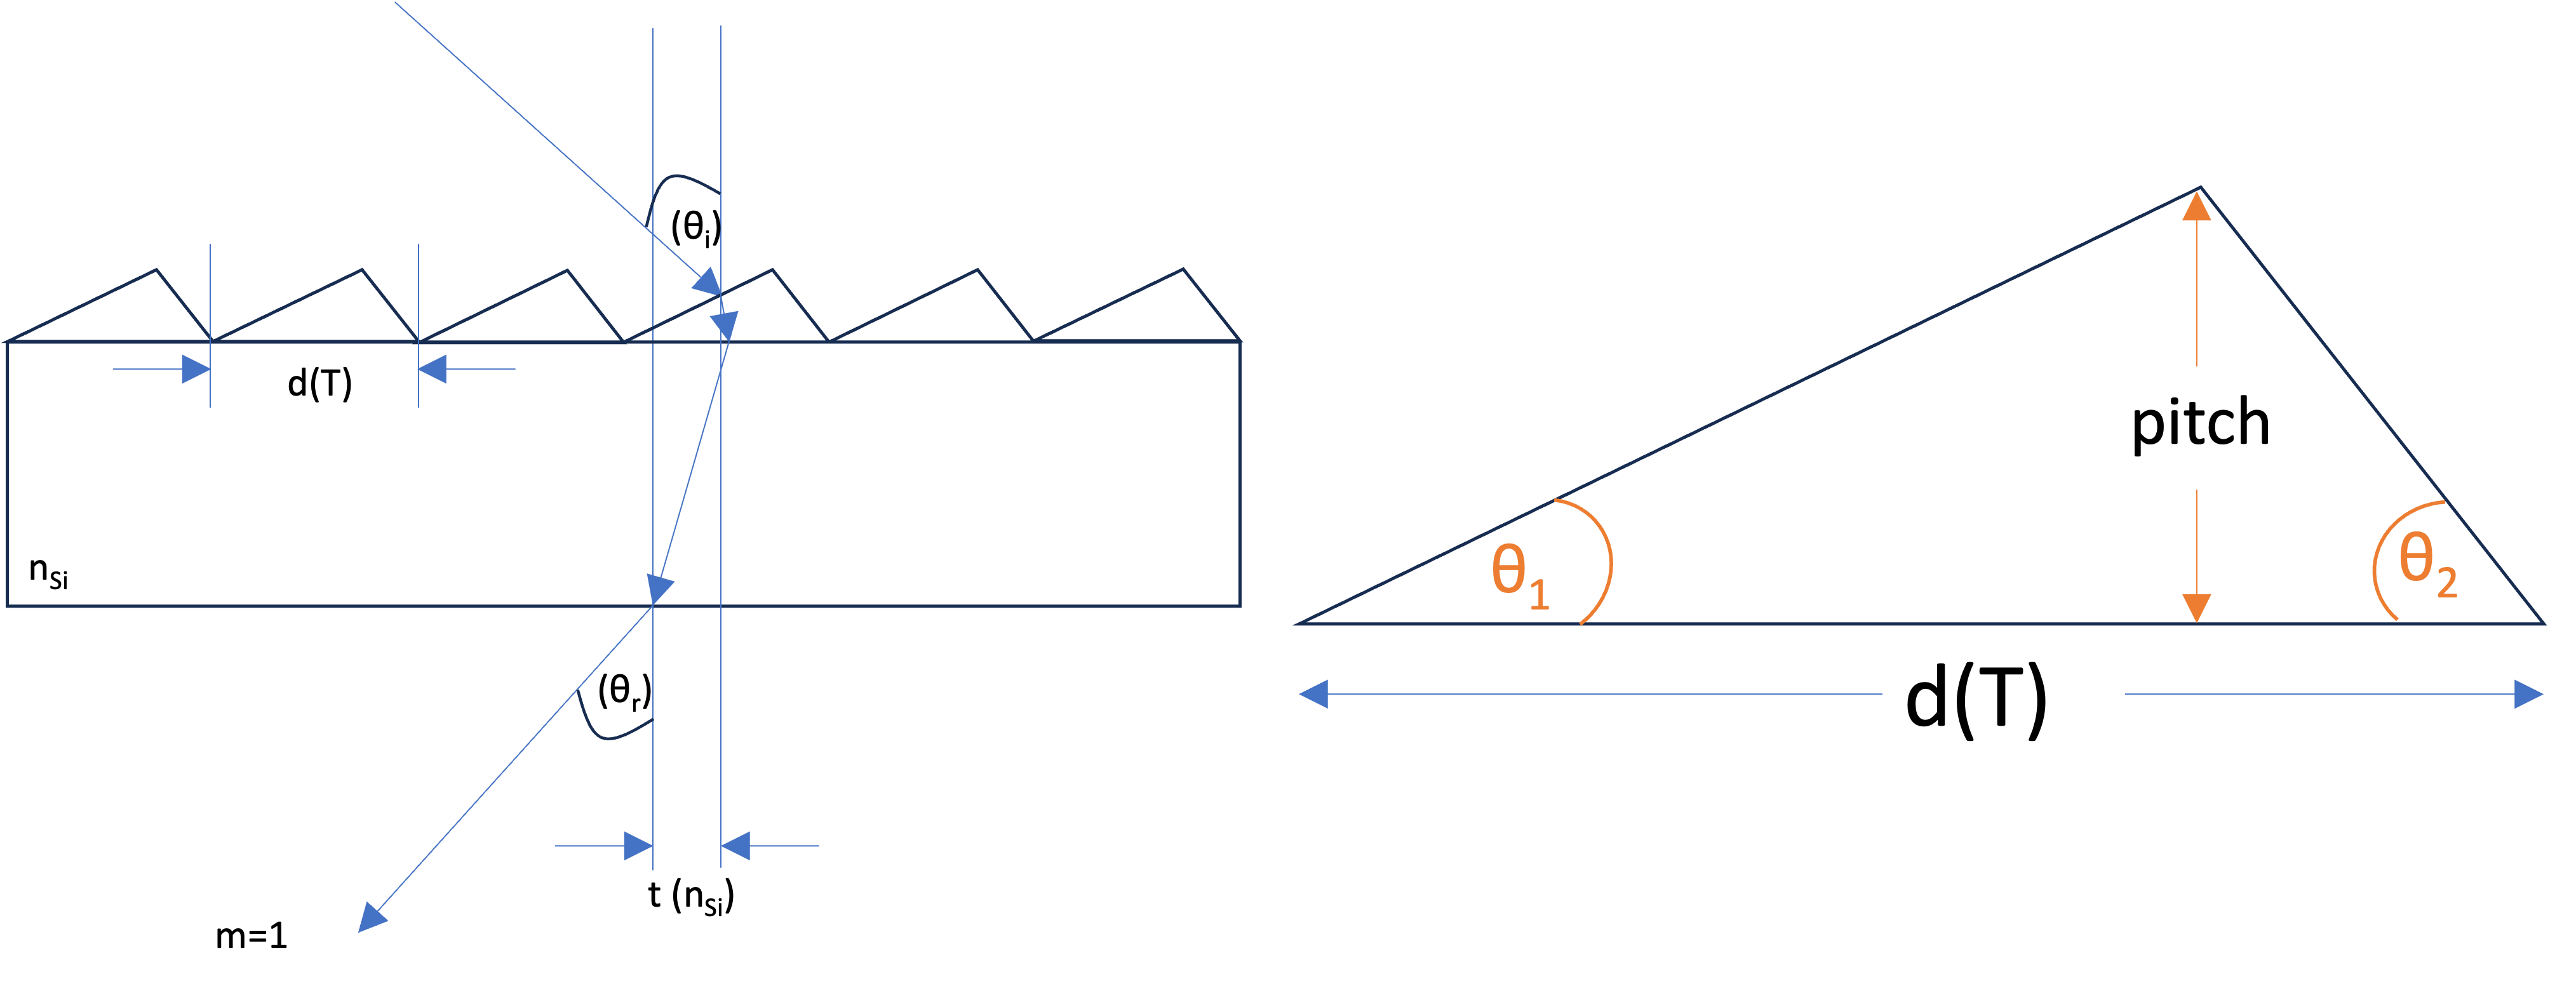

--- Reference geometry ---
lpm = 1503.7600 lines/mm, d0 = 0.6650 µm, theta_inc = 51.4400 deg
theta'_ref = 51.4399 deg at T_ref = 20.0 °C

--- Temperature sensitivity (vacuum) ---
dθ'/dT = -1.3799e-06 rad/°C = -1.380 µrad/°C = -0.285 arcsec/°C
Ground shift per °C @500 km = -0.69 m/°C


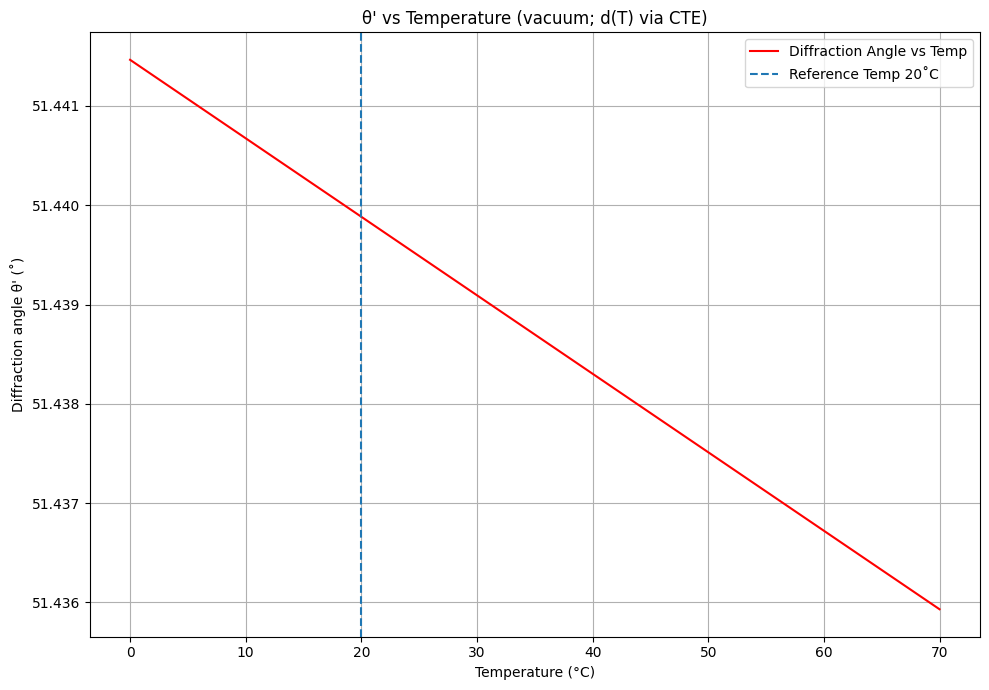

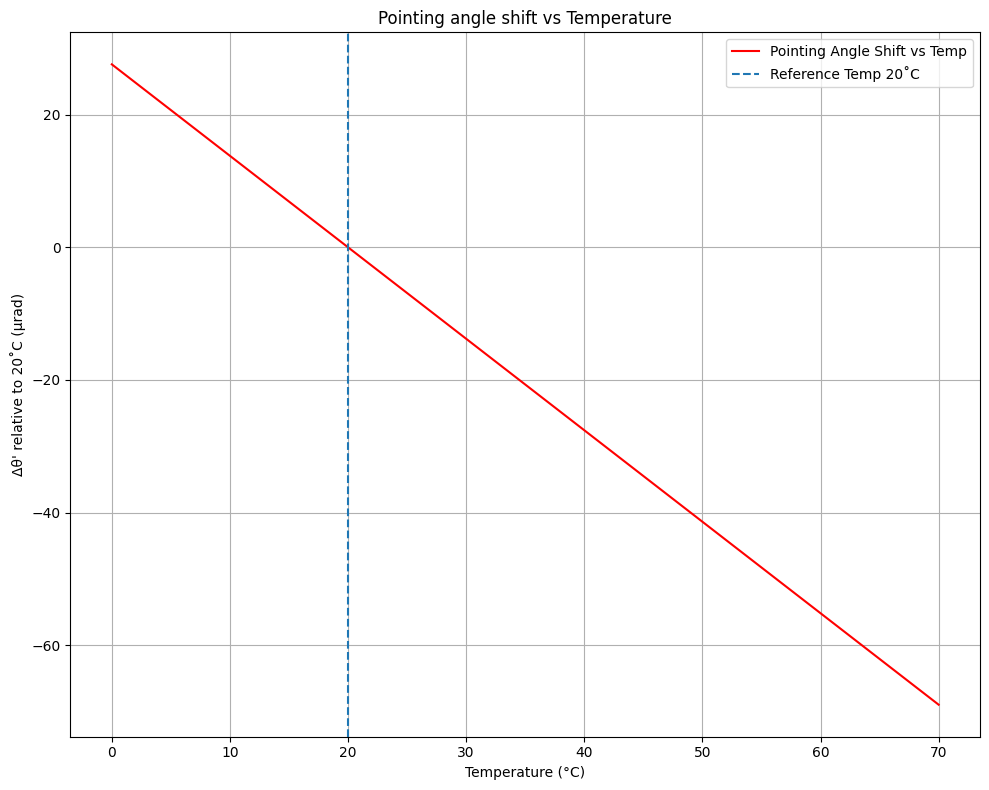

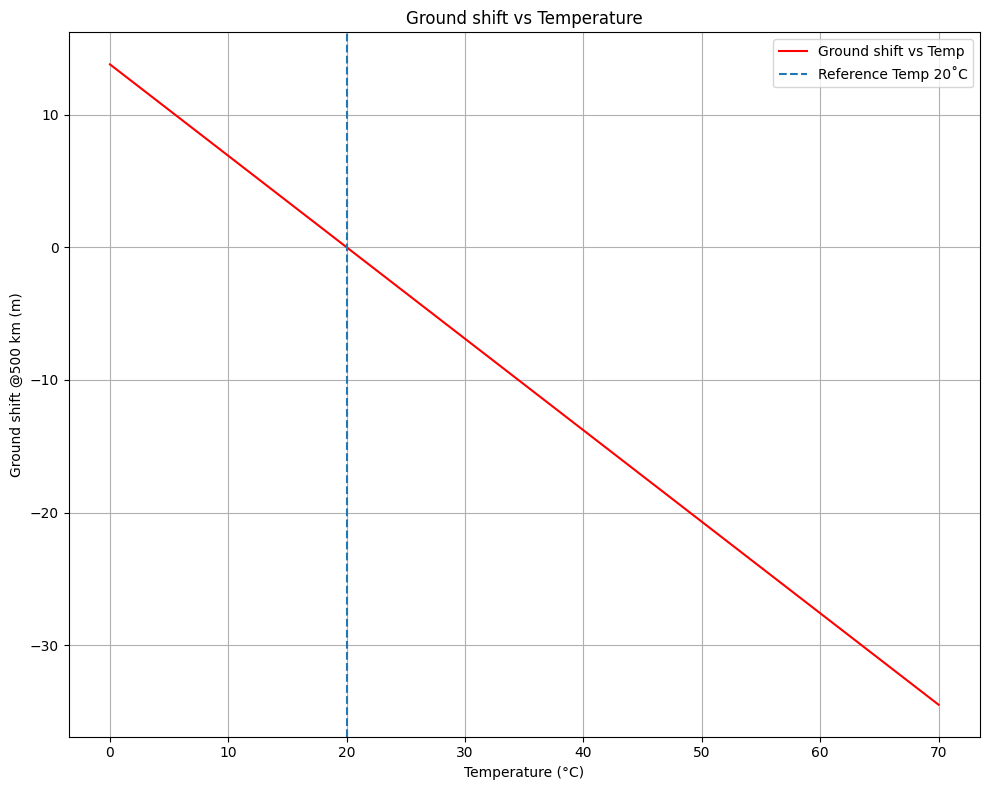

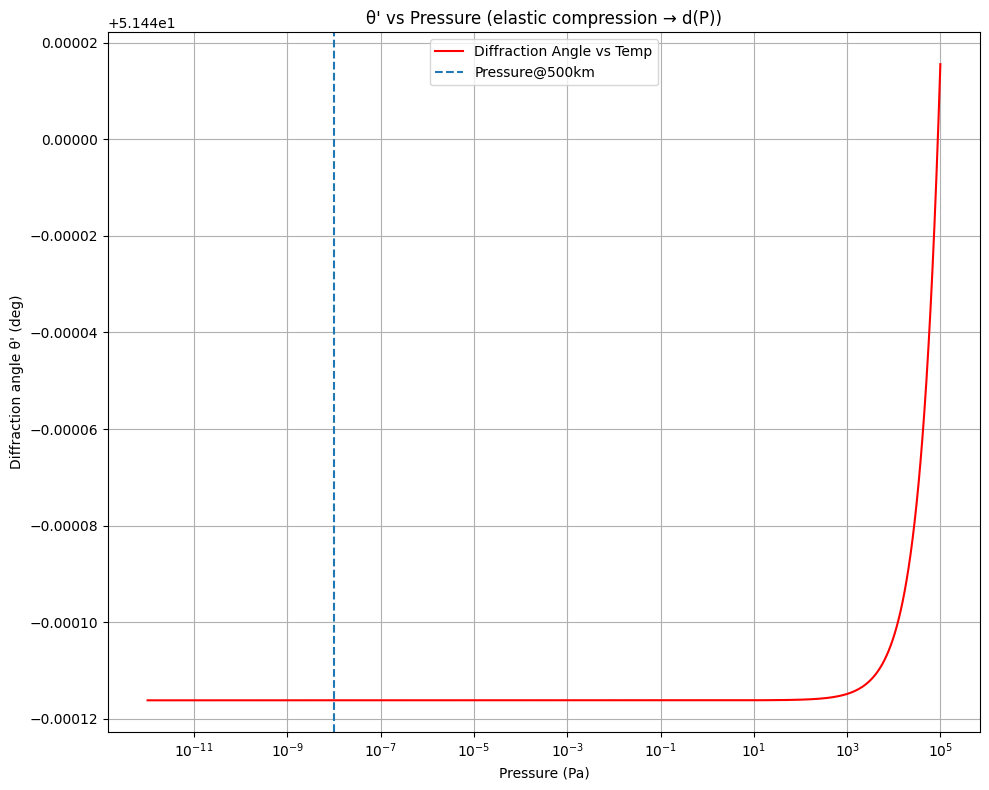

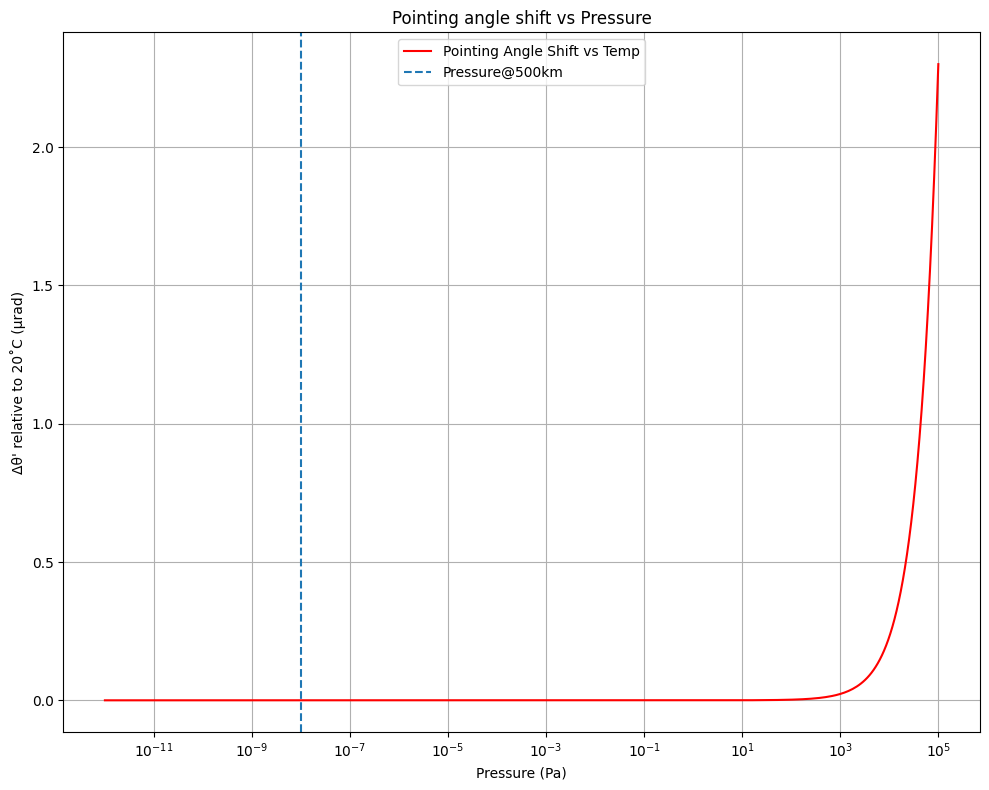

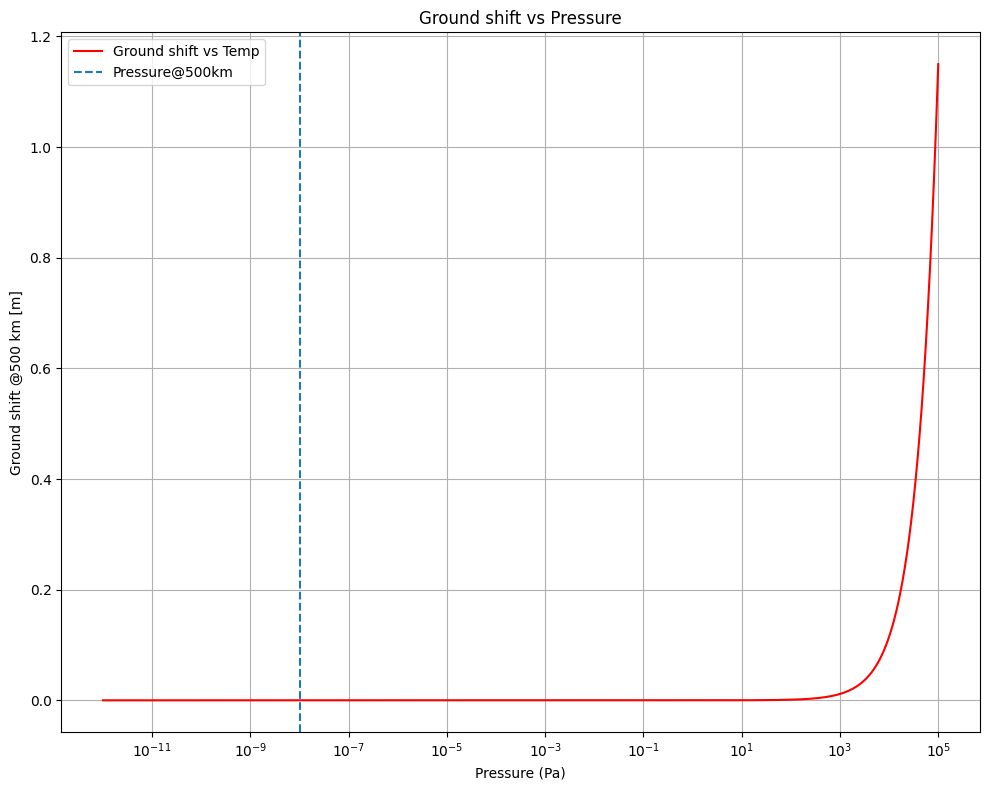


[1 atm] P = 1.013e+05 Pa
  Linear strain ε = -9.288e-07
  d(P) = 0.664999 µm (d0 = 0.665000 µm)
  θ'(P) = 51.440017 deg (ref = 51.439884 deg)
  Δθ' = 0.481 arcsec relative to ref
  Δθ' = 2.330 µrad relative to ref
  Ground shift @500 km = 1.165 m

[1e-8 Pa] P = 1.000e-08 Pa
  Linear strain ε = -9.167e-20
  d(P) = 0.665000 µm (d0 = 0.665000 µm)
  θ'(P) = 51.439884 deg (ref = 51.439884 deg)
  Δθ' = 0.000 arcsec relative to ref
  Δθ' = 0.000 µrad relative to ref
  Ground shift @500 km = 0.000 m

mHg] P = 1.003e+05 Pa
  Linear strain ε = -9.190e-07
  d(P) = 0.664999 µm (d0 = 0.665000 µm)
  θ'(P) = 51.440016 deg (ref = 51.439884 deg)
  Δθ' = 0.476 arcsec relative to ref
  Δθ' = 2.306 µrad relative to ref
  Ground shift @500 km = 1.153 m

mHg] P = 1.023e+05 Pa
  Linear strain ε = -9.374e-07
  d(P) = 0.664999 µm (d0 = 0.665000 µm)
  θ'(P) = 51.440019 deg (ref = 51.439884 deg)
  Δθ' = 0.485 arcsec relative to ref
  Δθ' = 2.352 µrad relative to ref
  Ground shift @500 km = 1.176 m

Saved: /Use

In [50]:
"""
Pointing & Diffraction Angle vs Temperature and Pressure
--------------------------------------------------------
Geometry: transmission grating, vacuum on both sides (n1=n2=1)
- Order: m = 1
- Wavelength: 1040 nm
- Line density: 1503.76 lines/mm (period d0 = 1/(lpm*1e3))
- Incidence angle: theta_inc ≈ 51.44 deg (near equal-angle for this d0 at 1040 nm)

Effects modeled
---------------
1) Temperature (vacuum):
   d(T) = d0 * (1 + alpha * ΔT) with alpha = 0.55e-6 /°C
   Use full grating equation m*λ = d(T) [ sinθ + sinθ'(T) ] to get θ'(T) (n1=n2=1).
   Analytic slope at reference T:
       dθ'/dT = -alpha * (sinθ + sinθ') / cosθ'   [rad/°C]
   Notes: dn/dT (8.6e-6 /°C for fused silica) mostly affects efficiency, and lateral shift across the grating material, 
          not pointing in this vacuum-on-both-sides geometry, so it is not applied.
          still need to figure out the effect of the saw tooth geometry

2) Pressure (elastic): hydrostatic pressure P causes volumetric strain ε_v = -P/K
   → linear isotropic strain ε = -P/(3K)
   → d(P) = d0 * (1 + ε). Fused silica bulk modulus K from E,ν.

Outputs
-------
- θ'(T) (deg), Δθ'(T) (arcsec), ground shift at 500 km vs T
- θ'(P) (deg), Δθ'(P) (arcsec), ground shift at 500 km vs P

DKR, 2025/08/20
"""
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Constants
m = 1
lambda0 = 1040e-9               # 1040 nm in meters
lpm = 1503.76                   # lines per mm from https://www.edmundoptics.com/p/ii-vi-lightsmytht-875nm-150376-groovesmm-248-x-158mm-transmission-diffraction-grating/44726/
theta_inc_deg = 51.44           # degrees
arcsec_per_rad = 3600*180/np.pi 
µrad_per_deg = np.pi*1e6/180    
arcsec_per_µrad = (180/np.pi)*3600*1e-6
µrad_per_arcsec = np.pi*1e6/180/3600

# Material properties
alpha = 0.55e-6                   # thermal expansion coeff (/°C); from https://accuratus.com/fused.html and https://www.translume.com/component/k2/item/186-fused-silica-material-properties#:~:text=Coefficient%20of%20Thermal%20Expansion%20(CTE)&text=Fused%20Silica%20Mean%20Coefficient%20of,200%C2%B0C%20temperature%20range
dn_dT = 8.6e-6                  # refractive index change per °C (approx); from 2006 NASA https://ntrs.nasa.gov/api/citations/20070018851/downloads/20070018851.pdf and 1971 NIST https://nvlpubs.nist.gov/nistpubs/jres/75a/jresv75an4p279_a1b.pdf

# Thermal properties
alpha = 0.55e-6                 # thermal expansion coeff (/°C)
dn_dT = 8.6e-6                  # thermo-optic of substrate (/°C) -- not used for pointing in vacuum

# Fused silica elastic properties
E = 72e9                        # Young's modulus [Pa]
nu = 0.17                       # Poisson's ratio [-]
K = E / (3.0 * (1.0 - 2.0*nu))  # Bulk modulus [Pa] ≈ 36.36 GPa

# Media: vacuum on both sides
n1 = 1.0
n2 = 1.0

# Mission geometry for converting angle shifts to ground displacement
altitude = 500e3                # 500 km in meters

# Sweeps
T_ref = 20.0                          # reference temperature [°C]
T_min, T_max, N_T = 0.0, 70.0, 251
P_min, P_max, N_P = 1e-12, 1e5, 400   # Pa (to ~1 atm)

# Specific pressures to report
P_atm = 101325.0                # Pa
P_uhv = 1e-8                    # Pa
p_752mmHg = 752 * 101325/760    # Pa 
p_767mmHg = 767 * 101325/760    # Pa 

# Output directory (Change directory to your desired location)
OUTDIR = Path('/Users/drai/Library/CloudStorage/OneDrive-NASA/Alicat/CASALS/0Code/0OutputData')

# Helpers
def grating_period_from_lpm(lpm: float) -> float:
# Convert line density ()lines/mm) to period [m]
    return 1.0 / (lpm * 1e3)

def diffracted_angle(m: int, lam: float, d: float, n1: float, n2: float, theta_inc: float) -> float:
# Return θ' [rad] from m*λ = d*(n1*sinθ + n2*sinθ')
    lhs = m * lam / d
    rhs = n1 * np.sin(theta_inc)
    arg = (lhs - rhs) / n2
    arg = np.clip(arg, -1.0, 1.0)
    return np.arcsin(arg)

def linear_strain_from_pressure(P: float, K: float) -> float:
# Isotropic linear strain under hydrostatic pressure P [Pa]
    return -P / (3.0 * K)

# Setup baseline geometry
d0 = grating_period_from_lpm(lpm)
theta_inc = np.deg2rad(theta_inc_deg)

# Reference diffracted angle at T_ref (vacuum)
theta_ref = diffracted_angle(m, lambda0, d0, n1, n2, theta_inc)
theta_ref_deg = np.rad2deg(theta_ref)

# Analytic temperature slope at reference
slope_rad_per_C = -alpha * (np.sin(theta_inc) + np.sin(theta_ref)) / np.cos(theta_ref)
slope_µrad_per_C = slope_rad_per_C *1e6
slope_arcsec_per_C = slope_rad_per_C * arcsec_per_rad
shift_m_per_C = slope_rad_per_C * altitude

print("--- Reference geometry ---")
print(f"lpm = {lpm:.4f} lines/mm, d0 = {d0*1e6:.4f} µm, theta_inc = {theta_inc_deg:.4f} deg")
print(f"theta'_ref = {theta_ref_deg:.4f} deg at T_ref = {T_ref:.1f} °C")
print("\n--- Temperature sensitivity (vacuum) ---")
print(f"dθ'/dT = {slope_rad_per_C:.4e} rad/°C = {slope_urad_per_C:.3f} µrad/°C = {slope_arcsec_per_C:.3f} arcsec/°C")
print(f"Ground shift per °C @500 km = {shift_m_per_C:.2f} m/°C")

# -----------------------------
# Temperature sweep
# -----------------------------
T_vec = np.linspace(T_min, T_max, N_T)

theta_T = np.empty_like(T_vec)
for i, T in enumerate(T_vec):
    dT = T - T_ref
    dT_val = d0 * (1.0 + alpha * dT)
    theta_T[i] = diffracted_angle(m, lambda0, dT_val, n1, n2, theta_inc)

theta_T_deg = np.rad2deg(theta_T)
delta_theta_T_arcsec = (theta_T_deg - theta_ref_deg) * 3600.0
delta_theta_T_µrad = (theta_T_deg - theta_ref_deg) * (np.pi*1e6/180)
ground_shift_T_m = np.deg2rad(theta_T_deg - theta_ref_deg) * altitude

# -----------------------------
# Pressure sweep
# -----------------------------
P_vec = np.logspace(np.log10(P_min), np.log10(P_max), N_P)

theta_P = np.empty_like(P_vec)
for i, P in enumerate(P_vec):
    eps = linear_strain_from_pressure(P, K)
    dP = d0 * (1.0 + eps)
    theta_P[i] = diffracted_angle(m, lambda0, dP, n1, n2, theta_inc)

theta_P_deg = np.rad2deg(theta_P)
delta_theta_P_arcsec = (theta_P_deg - theta_ref_deg) * 3600.0
delta_theta_P_µrad = (theta_P_deg - theta_ref_deg) * (np.pi*1e6/180)
ground_shift_P_m = np.deg2rad(theta_P_deg - theta_ref_deg) * altitude

# -----------------------------
# Plots
# -----------------------------
plt.figure(figsize=(10,7))
plt.plot(T_vec, theta_T_deg, color='red', label='Diffraction Angle vs Temp')
plt.xlabel("Temperature (°C)")
plt.ylabel("Diffraction angle θ' (˚)")
plt.title("θ' vs Temperature (vacuum; d(T) via CTE)")
plt.axvline(T_ref, linestyle='--', label='Reference Temp 20˚C')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10,8))
plt.plot(T_vec, delta_theta_T_µrad, color='red', label='Pointing Angle Shift vs Temp')
plt.xlabel("Temperature (°C)")
plt.ylabel("Δθ' relative to 20˚C (µrad)")
plt.title("Pointing angle shift vs Temperature")
plt.axvline(T_ref, linestyle='--', label='Reference Temp 20˚C')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10,8))
plt.plot(T_vec, ground_shift_T_m, color='red', label='Ground shift vs Temp')
plt.xlabel("Temperature (°C)")
plt.ylabel("Ground shift @500 km (m)")
plt.title("Ground shift vs Temperature")
plt.axvline(T_ref, linestyle='--', label='Reference Temp 20˚C')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10,8))
plt.semilogx(P_vec, theta_P_deg, color='red', label='Diffraction Angle vs Temp')
plt.xlabel("Pressure (Pa)")
plt.ylabel("Diffraction angle θ' (deg)")
plt.title("θ' vs Pressure (elastic compression → d(P))")
plt.axvline(P_uhv, linestyle='--', label='Pressure@500km')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10,8))
plt.semilogx(P_vec, delta_theta_P_µrad, color='red', label='Pointing Angle Shift vs Temp')
plt.xlabel("Pressure (Pa)")
plt.ylabel("Δθ' relative to 20˚C (µrad)")
plt.title("Pointing angle shift vs Pressure")
plt.axvline(P_uhv, linestyle='--', label='Pressure@500km')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()

plt.figure(figsize=(10,8))
plt.semilogx(P_vec, ground_shift_P_m, color='red', label='Ground shift vs Temp')
plt.xlabel("Pressure (Pa)")
plt.ylabel("Ground shift @500 km [m]")
plt.title("Ground shift vs Pressure")
plt.axvline(P_uhv, linestyle='--', label='Pressure@500km')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()

plt.show()

# Reports for specific pressures

def report_pressure(tag: str, P: float) -> None:
    eps = linear_strain_from_pressure(P, K)
    dP = d0 * (1.0 + eps)
    th = diffracted_angle(m, lambda0, dP, n1, n2, theta_inc)
    th_deg = np.rad2deg(th)
    dth_arcsec = (th_deg - theta_ref_deg) * 3600.0
    dth_µrad = (th_deg - theta_ref_deg) * (np.pi*1e6/180)
    ground_shift_m = np.deg2rad(th_deg - theta_ref_deg) * altitude
    print(f"\n[{tag}] P = {P:.3e} Pa")
    print(f"  Linear strain ε = {eps:.3e}")
    print(f"  d(P) = {dP*1e6:.6f} µm (d0 = {d0*1e6:.6f} µm)")
    print(f"  θ'(P) = {th_deg:.6f} deg (ref = {theta_ref_deg:.6f} deg)")
    print(f"  Δθ' = {dth_arcsec:.3f} arcsec relative to ref")
    print(f"  Δθ' = {dth_µrad:.3f} µrad relative to ref")
    print(f"  Ground shift @500 km = {ground_shift_m:.3f} m")

report_pressure("1 atm", P_atm)
report_pressure("1e-8 Pa", P_uhv)
report_pressure("752mmHg", p_752mmHg)
report_pressure("767mmHg", p_767mmHg)

# Save CSVs

df_T = pd.DataFrame({
    "Temperature_C": T_vec,
    "theta_deg": theta_T_deg,
    "delta_theta_arcsec": delta_theta_T_arcsec,
    "ground_shift_m": ground_shift_T_m,
})

df_P = pd.DataFrame({
    "Pressure_Pa": P_vec,
    "theta_deg": theta_P_deg,
    "delta_theta_arcsec": delta_theta_P_arcsec,
    "ground_shift_m": ground_shift_P_m,
})

out_T = OUTDIR / "diffraction_pointing_vs_temperature.csv"
out_P = OUTDIR / "diffraction_pointing_vs_pressure.csv"
df_T.to_csv(out_T, index=False)
df_P.to_csv(out_P, index=False)

print(f"\nSaved: {out_T.resolve()}\nSaved: {out_P.resolve()}")
